#### I'm going to try out complex exponential smoothing in this notebook

In [1]:
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train_df = pd.read_csv("DailyDelhiClimateTrain.csv")
test_df = pd.read_csv("DailyDelhiClimateTest.csv")

In [3]:
train_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


### I'm going to try and predict the temperature. My metric will be the RMSE

### Preprocessing

In [4]:
train_df.isna().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [5]:
test_df.isna().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

### The dataset contains no missing values

In [6]:
train_df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


Several variables contain outliers, but the most problematic ones appear in `meanpressure`.
The mean is around 1011, while the maximum reaches 7679, whereas the 75% quantile is only 1014.
This indicates the presence of extreme abnormal values.
 
To handle them, I clip the pressure values using empirical quantiles.
After plotting the distribution restricted to the interval between the $\alpha$ and $1-\alpha$ quantiles for several values of $\alpha$,
I observed that taking $\alpha = 0.01$ retains almost all of the meaningful mass of the distribution.

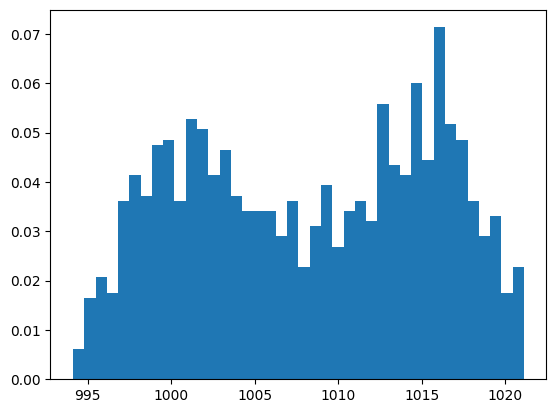

In [7]:
pressure = np.array(train_df["meanpressure"])
sorted_pressure = np.sort(pressure)
n = len(pressure)
plt.hist(sorted_pressure[int(0.01*n):int(0.99*n)], bins=40, density=True)
plt.show()


np.mean(pressure)

pressure_inf = sorted_pressure[int(0.01*n)]
pressure_sup = sorted_pressure[int(0.99*n)]

train_df["meanpressure_clipped"] = train_df["meanpressure"].clip(lower=pressure_inf, upper=pressure_sup)
test_df["meanpressure_clipped"] = test_df["meanpressure"].clip(lower=pressure_inf, upper=pressure_sup)


 ### Plotting the temperature series to get an initial sense of its temporal structure

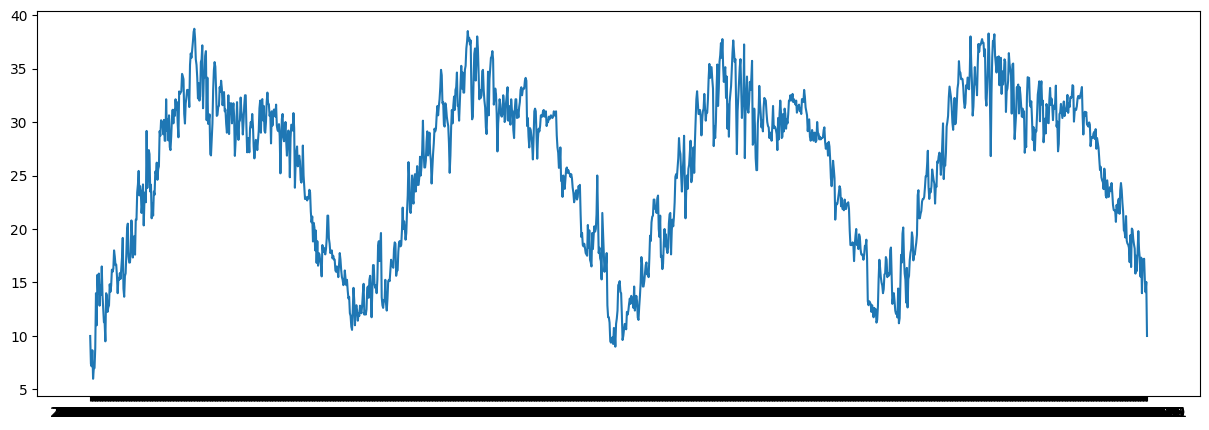

In [8]:
plt.figure(figsize=(15,5))
plt.plot(train_df["date"], train_df["meantemp"])
plt.show()


 As expected, the temperature exhibits a clear cyclical pattern.
 Capturing this periodic structure will be essential for accurate prediction.


 Next, I examine the distributions of the input variables.

C:\Users\tiots\AppData\Local\Temp\ipykernel_25900\3336102658.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1,0].legend()


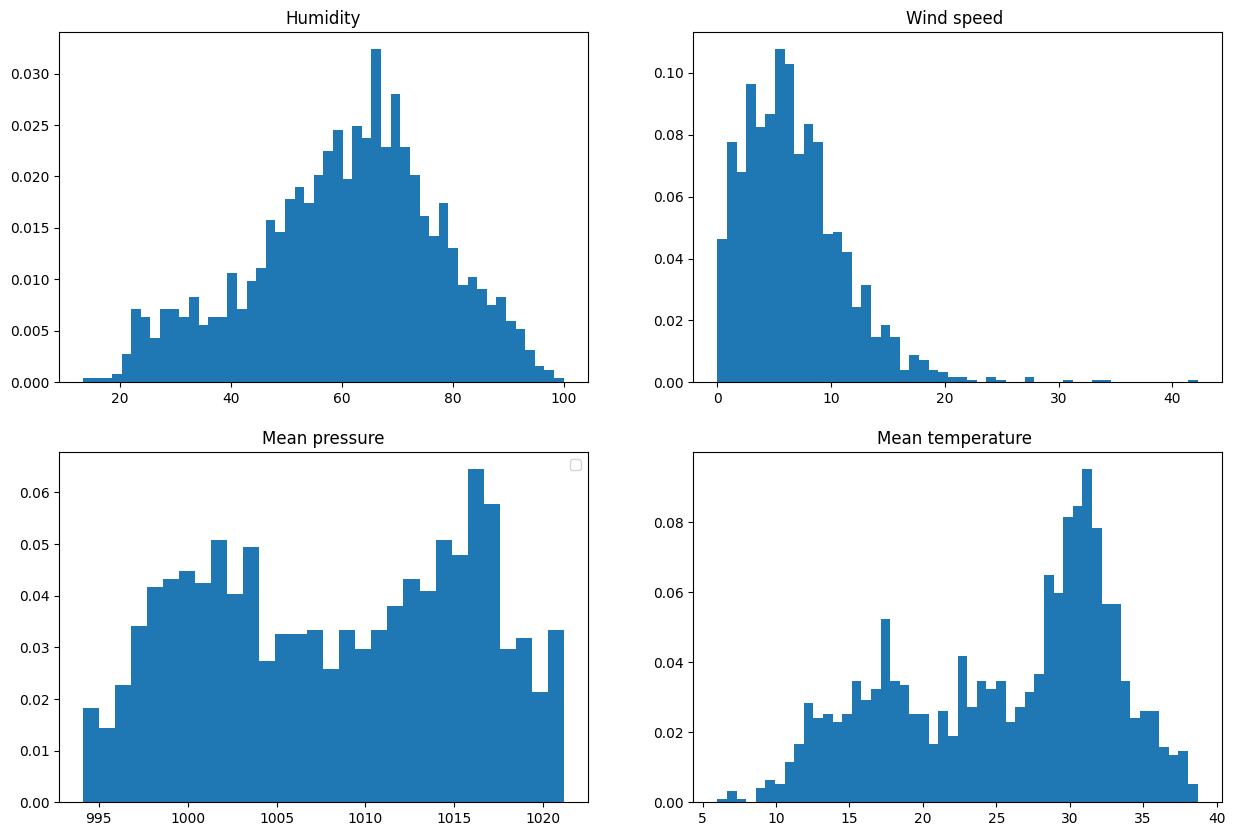

In [9]:
### Exploring other features
fig, ax = plt.subplots(figsize=(15,10), nrows=2, ncols=2)
ax[0,0].hist(train_df["humidity"], bins=50, density=True)
ax[0,0].set_title("Humidity")


ax[0,1].hist(train_df["wind_speed"], bins=50,density=True)
ax[0,1].set_title("Wind speed ")

ax[1,0].hist(train_df["meanpressure_clipped"], bins=30,density=True)
ax[1,0].set_title("Mean pressure")
ax[1,0].legend()

ax[1,1].hist(train_df["meantemp"], bins=50,density=True)
ax[1,1].set_title("Mean temperature ")
plt.show()

In [10]:
### To get things going, I convert the date into a number
train_df["date"] = pd.to_datetime(train_df["date"])
origine = train_df["date"].min()
train_df["date_num"] = train_df["date"] - origine
train_df["date_num"] = train_df["date_num"].dt.days

train_df = train_df.drop(columns=["date"])

### To get things going, I convert the date into a number
test_df["date"] = pd.to_datetime(test_df["date"])
test_df["date_num"] = test_df["date"] - origine
test_df["date_num"] = test_df["date_num"].dt.days

test_df = test_df.drop(columns=["date"])

In [11]:
train_df.head()

,meantemp,humidity,wind_speed,meanpressure,meanpressure_clipped,date_num
0,10.000000,84.500000,0.000000,1015.666667,1015.666667,0
1,7.400000,92.000000,2.980000,1017.800000,1017.800000,1
2,7.166667,87.000000,4.633333,1018.666667,1018.666667,2
3,8.666667,71.333333,1.233333,1017.166667,1017.166667,3
4,6.000000,86.833333,3.700000,1016.500000,1016.500000,4



 Scaling the variables before training

In [49]:
from sklearn.preprocessing import StandardScaler
from statsforecast import StatsForecast
from statsforecast.models import AutoCES
import scipy.stats as sps
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

df = pd.DataFrame({
    "unique_id": "Temperature",
    "ds": train_df["date_num"],
    "y" : train_df["meantemp"]
})

In [13]:
sf = StatsForecast(
    models=[AutoCES(season_length=365, model='Z', alias = "CES_365"), AutoCES(season_length=31, model='Z', alias = "CES_31")],
    freq=1
)

forecast = sf.forecast(df=df, h=114, fitted=True)
fitted = sf.forecast_fitted_values()

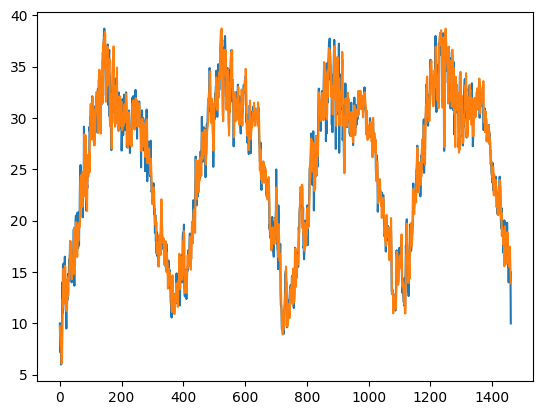

In [14]:
plt.plot(range(len(train_df)), train_df["meantemp"])
plt.plot(range(len(train_df)), fitted["CES_365"])

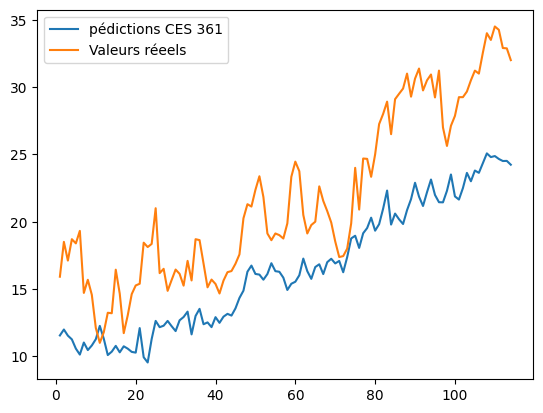

In [15]:
plt.plot(range(1,115), forecast["CES_365"], label="pédictions CES 361")
plt.plot(range(1,115),test_df["meantemp"], label="Valeurs réeels")
plt.legend()
plt.show()

In [16]:
### RMSE 
rmse = np.sqrt(np.mean((forecast['CES_365'] - test_df["meantemp"])**2))
print(f" The RMSE for the CES full forecasting on the test dataset  is {rmse:.2f}")

r2 = 1 - sum((forecast["CES_365"] - test_df["meantemp"])**2)/sum((test_df["meantemp"] - np.mean(test_df["meantemp"]))**2)
print(f"R^2 : {r2:.2f}")

 The RMSE for the CES full forecasting on the test dataset  is 5.83
R^2 : 0.15


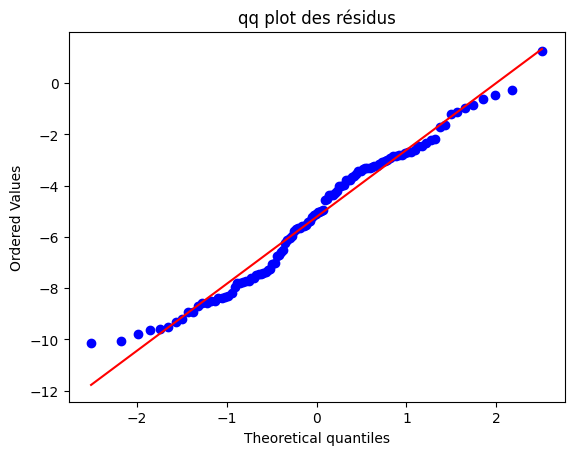

In [17]:
### qqplot for the residuals : 
residuals = forecast['CES_365'] - test_df["meantemp"]
sps.probplot(residuals, dist="norm", plot=plt)
plt.title("qq plot des résidus")
plt.show()

##### On a des résidus énormes et dont les quantiles s'alignent plus ou moins bien avec ceux de la loi normale. On va essayer de faire un rolling one step ahead pour comparer avec l'arima

In [18]:
def rolling_one_step(y_train, y_test, season_length=365, model_type="Z"):
    y_train = np.asarray(y_train, dtype=float)
    y_test = np.asarray(y_test, dtype=float)

    model = AutoCES(
        season_length=season_length,
        model=model_type,
        alias=f"CES_{season_length}"
    )

    # Fit once
    model.fit(y_train)

    preds = []

    for i in range(len(y_test)):
        # Series observed till y_test[i]:
        # train + true values already revealed
        y_seen = np.concatenate([y_train, y_test[:i]])

        # Forward = keeps the estimated parameters,
        # updates states until the last seen element
        fcst = model.forward(y=y_seen, h=1)

        preds.append(fcst["mean"][0])

    results = pd.DataFrame({
        "t": np.arange(len(y_test)),
        "y_true": y_test,
        "y_pred": preds,
        "residual": y_test - np.array(preds)
    })

    return results, model

In [19]:
results, model = rolling_one_step(train_df["meantemp"], test_df["meantemp"], season_length=365)

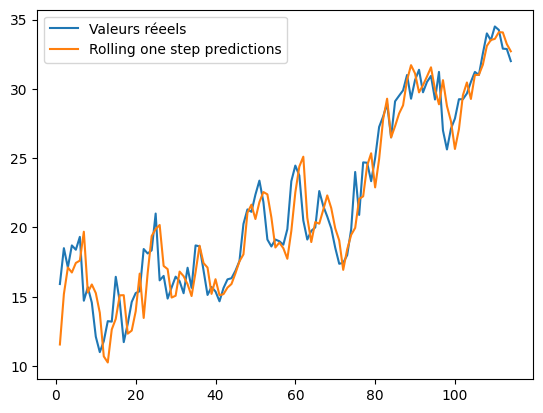

In [20]:
plt.plot(range(1,115),test_df["meantemp"], label="Valeurs réeels")
plt.plot(range(1,115), results["y_pred"], label="Rolling one step predictions")
plt.legend()
plt.show()

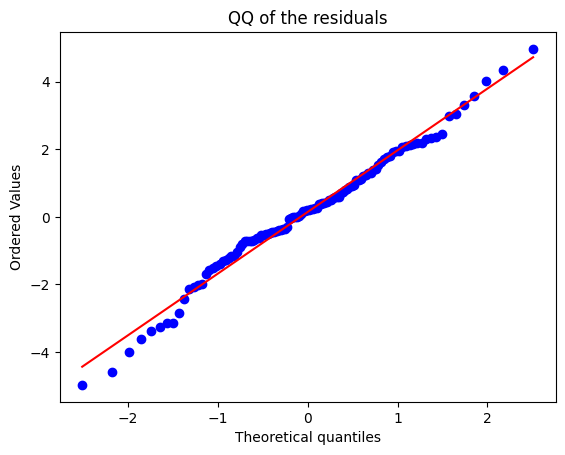

In [21]:
sps.probplot(results["residual"], dist='norm', plot=plt)
plt.title("QQ of the residuals")
plt.show()

In [157]:
### RMSE : 
rmse = np.sqrt(np.mean(results["residual"]**2))
print(f"RMSE for rolling one step predictions, CES : {rmse:.4f}")

r2 = 1 - sum((results["residual"])**2)/sum((test_df["meantemp"]- np.mean(test_df["meantemp"]))**2)
print(f"R^2 : {r2:.2f}")

RMSE for rolling one step predictions, CES : 1.8132
R^2 : 0.92


#### Conclusion

The one time step prediction is not as accurate as the ARIMA, but the advantage of this approach is it's simplicity. We only had to train 2 parameters, without detrending, deseasonalizing the series, which makes it quite simple to use and train. The only problem is that for full forecasting, it is not better than the simple sinusoidal seasonal pattern + the trend pattern, which is why it yields a $R^2$ of nd a RMSE of $5.83$. 

#### Training a LSTM model 

In [23]:
y_train = np.array(train_df["meantemp"])
y_test = np.array(test_df["meantemp"])

In [24]:
import torch
import torch.nn as nn

In [26]:
torch.cuda.is_available()

True

In [27]:
def make_windows_multi_horizon(y, lookback, horizon = 114): ### Create the windows to be used to train and the values we're trying to predict
    X, Y = [], []
    for i in range(lookback, len(y)-horizon+1):
        X.append(y[i-lookback:i])
        Y.append(y[i:i+horizon])
    return np.array(X), np.array(Y)

train_size= int(0.8*len(y_train))
train = y_train[:train_size]
val = y_train[train_size:]


In [28]:
horizon = len(y_test)
lookback = 365
X, Y = make_windows_multi_horizon(train, lookback=lookback, horizon = horizon)

In [29]:
class myLSTM (nn.Module):
    def __init__(self,
                 input_size=1,
                 hidden_size=64,
                 num_layers = 1,
                 horizon = 1, 
                 dropout= 0.0):
        super().__init__()
        
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first = True,
                            dropout = dropout if num_layers>1 else 0)
        
        self.fc = nn.Linear(hidden_size, horizon)
        
    def forward(self, x):
        ## I receive a batch: its shape is batch x lookback x 1
        out, _ = self.lstm(x)
        
        ## I retreive the last hidden state
        last_hidden = out[:,-1,:]
        
        ## forecast 
        forecast = self.fc(last_hidden)
        
        return forecast
        

In [30]:
scaler = StandardScaler()
y_train_scaled = scaler.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_scaled = scaler.transform(y_test.reshape(-1,1)).ravel()


X_train, Y_train = make_windows_multi_horizon(y_train_scaled, lookback=365, horizon= 114)

In [31]:
print("X_train shape : ", X_train.shape)
print("Y_train shape : ", Y_train.shape)

X_train shape :  (984, 365)
Y_train shape :  (984, 114)


In [32]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)

dataset = torch.utils.data.TensorDataset(X_train_t, Y_train_t)
loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle= True
)

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = myLSTM(input_size=1,
               hidden_size=32,
               num_layers=1,
               horizon = horizon,
               dropout= 0.0).to(device)

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def rolling_horizon_lstm(
    model,
    y_train_scaled,
    y_test_scaled,
    scaler,
    lookback,
    horizon,
    device
):
    """
    Rolling horizon forecasting.

    At each iteration :
    - I take the lookback previous observed values ;
    - I predict horizon points ;
    - Add the true values of the target in my history ;
    - Use these previous values and the history in my lookback to predict the next horizon values

    The model should be trained to give an output of length horizon.
    """

    model.eval()
    model = model.to(device)

    history_values = list(y_train_scaled)
    preds_scaled = []

    with torch.no_grad():
        for start in range(0, len(y_test_scaled), horizon):
            end = min(start + horizon, len(y_test_scaled))
            block_len = end - start

            last_window = np.array(history_values[-lookback:], dtype=float)

            x = torch.tensor(
                last_window,
                dtype=torch.float32
            ).view(1, lookback, 1).to(device)

            pred_block_scaled = model(x).cpu().numpy().ravel()

            pred_block_scaled = pred_block_scaled[:block_len]

            preds_scaled.extend(pred_block_scaled)

            # Rolling by chunk
            history_values.extend(y_test_scaled[start:end])

    preds_scaled = np.array(preds_scaled)

    preds = scaler.inverse_transform(
        preds_scaled.reshape(-1, 1)
    ).ravel()

    return preds

In [141]:
def train(y_train, 
          y_val, 
          hidden_size = 64, 
          num_layers = 1, 
          dropout =0,
          epochs = 300,
          batch_size=32,
          lr= 1e-3,
          weight_decay = 1e-4,
          lookback= 365,
          horizon = 114,
          rolling = False):
    criterion = nn.MSELoss()
    model = myLSTM(1, hidden_size, num_layers, horizon = horizon, dropout = dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay = weight_decay)
    history = []

    X_train, Y_train = make_windows_multi_horizon(y_train, lookback, horizon)
    
    X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
    Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
    dataset = torch.utils.data.TensorDataset(X_train_t, Y_train_t)
    
    loader = torch.utils.data.DataLoader(
        dataset, 
        batch_size= batch_size,
        shuffle= True
    )
    for epoch in range(epochs):
        model.train() # Get in train mode 
        total_loss = 0
        for xb, yb in loader:
            xb = xb.to(device)  ##Load the x and y in the device
            yb = yb.to(device)
            
            optimizer.zero_grad()
            
            pred = model(xb)
            loss = criterion(pred, yb)
            
            loss.backward()### Compute the gradients
            optimizer.step() ### modify the parameters
            
            total_loss += loss.item()*xb.size(0) ### Non-normalized error for the batch
            
        avg_loss = total_loss/len(dataset)
        history.append(avg_loss)
            
        last_window = y_train[-lookback:]

        X_forecast = torch.tensor(
            last_window,
            dtype=torch.float32
        ).view(1, lookback, 1).to(device)

        with torch.no_grad():
            pred_val_scaled = model(X_forecast).cpu().numpy().ravel()

        pred_val = scaler.inverse_transform(
            pred_val_scaled.reshape(-1, 1)
        ).ravel()

        pred_val = pred_val[:len(y_val)]
        y_val_real = scaler.inverse_transform(
            y_val.reshape(-1,1)
        ).ravel()
        
        if rolling :
            pred_val = rolling_horizon_lstm(model, y_train, y_val, scaler, lookback, horizon, device)
        mae = mean_absolute_error(pred_val, y_val_real)
        rmse = root_mean_squared_error(pred_val, y_val_real)
        
        if epoch == epochs-1:
            print(f"Epoch {epoch+1}/{epochs}, train loss = {avg_loss:.6f}")
            print(f"RMSE : {rmse:.6f}, MAE : {mae:.6f}")

    return history, model, mae, rmse, pred_val, count_parameters(model)
            

In [122]:
import random 

n = len(y_train_scaled)
y_train = y_train_scaled[:-horizon]
y_val = y_train_scaled[-horizon:]

hidden_size_vals = [16, 32, 64, 96]
num_layers_vals = [1, 2]
dropout_vals = [0, 0.1, 0.2, 0.3]
batch_size_vals = [8, 16, 32]
lr_vals = [1e-3, 1e-4, 1e-5]
weight_decay_vals = [1e-6, 1e-3]

best_model = None
best_params = None
best_history = None
best_mae = float("inf")
best_rmse = float("inf")

tested_models = []

n_iter = 20

for iter in range(n_iter):
    if iter % 10 == 0:
        print(f"Iteration number {iter+1}")

    hidden_size = random.choice(hidden_size_vals)
    num_layers = random.choice(num_layers_vals)
    dropout = random.choice(dropout_vals)
    lr = random.choice(lr_vals)  
    batch_size = random.choice(batch_size_vals)
    weight_decay = random.choice(weight_decay_vals)

    history, model, mae, rmse, preds, n_params = train(
        y_train,
        y_val,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        epochs=150,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay
    )

    params = {
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "dropout": dropout,
        "lr": lr,
        "batch_size": batch_size,
        "weight_decay": weight_decay,
    }

    model_info = {
        "iteration": iter + 1,
        "params": params,
        "mae": mae,
        "rmse": rmse,
        "history": history,
        "preds": preds,
        "n_params": n_params,
        "model": model,
    }

    tested_models.append(model_info)

    if rmse < best_rmse:
        best_model = model
        best_mae = mae
        best_history = history
        best_rmse = rmse
        best_params = (
            hidden_size,
            num_layers,
            dropout,
            lr,
            batch_size,
            weight_decay
        )

Iteration number 1
Epoch 150/150, train loss = 0.001908
RMSE : 5.297099, MAE : 4.291940
Epoch 150/150, train loss = 0.000714
RMSE : 4.737279, MAE : 4.487742
Epoch 150/150, train loss = 0.000422
RMSE : 6.055858, MAE : 5.653441
Epoch 150/150, train loss = 0.000625
RMSE : 5.077672, MAE : 4.833505
Epoch 150/150, train loss = 0.000661
RMSE : 4.238856, MAE : 4.014921
Epoch 150/150, train loss = 0.000688
RMSE : 2.899769, MAE : 2.516050
Epoch 150/150, train loss = 0.000271
RMSE : 5.381887, MAE : 4.955212
Epoch 150/150, train loss = 0.000459
RMSE : 5.398551, MAE : 5.133566
Epoch 150/150, train loss = 0.000576
RMSE : 3.615117, MAE : 3.324552
Epoch 150/150, train loss = 0.001619
RMSE : 4.121359, MAE : 3.514208
Iteration number 11
Epoch 150/150, train loss = 0.004171
RMSE : 4.813942, MAE : 3.860834
Epoch 150/150, train loss = 0.000310
RMSE : 3.770567, MAE : 3.369323
Epoch 150/150, train loss = 0.000718
RMSE : 5.205463, MAE : 4.889843
Epoch 150/150, train loss = 0.000580
RMSE : 4.351155, MAE : 4.09

In [ ]:
summary = pd.DataFrame([
    {
        "iteration": m["iteration"],
        "hidden_size": m["params"]["hidden_size"],
        "num_layers": m["params"]["num_layers"],
        "dropout": m["params"]["dropout"],
        "lr": m["params"]["lr"],
        "batch_size": m["params"]["batch_size"],
        "weight_decay": m["params"]["weight_decay"],
        "mae": m["mae"],
        "rmse": m["rmse"],
        "n_params": m["n_params"],
    }
    for m in tested_models
])

summary = summary.sort_values("rmse").reset_index(drop=True)

summary.head()

,iteration,hidden_size,num_layers,dropout,lr,batch_size,weight_decay,mae,rmse,n_params
0,4,32,1,0.2,0.00010,8,0.000001,1.262600,1.529851,8242
1,11,16,1,0.2,0.00010,16,0.001000,1.392368,1.787670,3154
2,17,96,2,0.1,0.00100,16,0.000001,2.756567,3.221476,123570
3,6,96,2,0.1,0.00001,32,0.001000,2.721439,3.387609,123570
4,1,96,2,0.3,0.00100,8,0.001000,3.570956,3.918267,123570


In [87]:
print(f"Best rmse : {best_rmse}")
print(f"Best mae : {best_mae}")

Best rmse : 1.5140348516424984
Best mae : 1.2114851956465897


In [ ]:
# Getting the top 3 models
top3 = sorted(tested_models, key=lambda m: m["rmse"])[:3]

for i, m in enumerate(top3, 1):
    print(f"\nTop {i}")
    print("Iteration :", m["iteration"])
    print("Params    :", m["params"])
    print("Val MAE   :", m["mae"])
    print("Val RMSE  :", m["rmse"])
    print("n_params  :", m["n_params"])


Top 1
Iteration : 4
Params    : {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0001, 'batch_size': 8, 'weight_decay': 1e-06}
Val MAE   : 1.2625997093093466
Val RMSE  : 1.5298505595229612
n_params  : 8242

Top 2
Iteration : 11
Params    : {'hidden_size': 16, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0001, 'batch_size': 16, 'weight_decay': 0.001}
Val MAE   : 1.3923676630903505
Val RMSE  : 1.7876702213392879
n_params  : 3154

Top 3
Iteration : 17
Params    : {'hidden_size': 96, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 16, 'weight_decay': 1e-06}
Val MAE   : 2.756566991595512
Val RMSE  : 3.221475695858865
n_params  : 123570


In [111]:
def forecast_test_with_model(model, y_train_scaled, lookback, scaler, device):
    model.eval()
    model = model.to(device)

    last_window = y_train_scaled[-lookback:]

    X_forecast = torch.tensor(
        last_window,
        dtype=torch.float32
    ).view(1, lookback, 1).to(device)

    with torch.no_grad():
        pred_scaled = model(X_forecast).cpu().numpy().ravel()

    pred = scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).ravel()

    return pred


Top 1 test performance
Params   : {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0001, 'batch_size': 8, 'weight_decay': 1e-06}
Test MAE : 2.1577
Test RMSE: 2.6321
Test R2  : 0.8272

Top 2 test performance
Params   : {'hidden_size': 16, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0001, 'batch_size': 16, 'weight_decay': 0.001}
Test MAE : 3.8463
Test RMSE: 4.5780
Test R2  : 0.4773

Top 3 test performance
Params   : {'hidden_size': 96, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 16, 'weight_decay': 1e-06}
Test MAE : 3.0359
Test RMSE: 3.6816
Test R2  : 0.6620


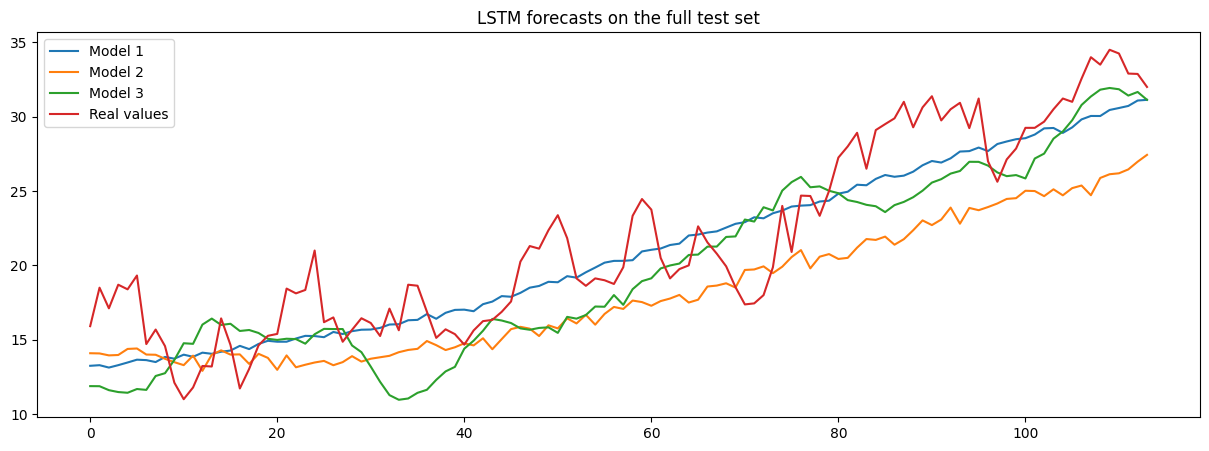

In [ ]:
top3_forecasts = {}
plt.figure(figsize=(15,5))
for i, m in enumerate(top3, 1):
    model = m["model"]

    pred_test = forecast_test_with_model(
        model=model,
        y_train_scaled=y_train_scaled,
        lookback=lookback,
        scaler=scaler,
        device=device
    )

    pred_test = pred_test[:len(y_test)]
    plt.plot(range(len(pred_test)), pred_test,label=f"Model {i}")
    mae = mean_absolute_error(y_test, pred_test)
    rmse = root_mean_squared_error(y_test, pred_test)
    r2 = r2_score(y_test, pred_test)

    top3_forecasts[f"top_{i}"] = {
        "model": model,
        "params": m["params"],
        "val_rmse": m["rmse"],
        "test_pred": pred_test,
        "test_mae": mae,
        "test_rmse": rmse,
        "test_r2": r2,
    }

    print(f"\nTop {i} test performance")
    print("Params   :", m["params"])
    print(f"Test MAE : {mae:.4f}")
    print(f"Test RMSE: {rmse:.4f}")
    print(f"Test R2  : {r2:.4f}")
    
plt.plot(range(len(pred_test)), y_test, label="Real values")
plt.title("LSTM forecasts on the full test set")
plt.legend()
plt.show()

In [147]:
### Train for the one time step predictions 

horizon = 1 

y_train = y_train_scaled[:-114]
y_val = y_train_scaled[-114:]

hidden_size_vals = [16, 32, 64, 96]
num_layers_vals = [1, 2]
dropout_vals = [0, 0.1, 0.2, 0.3]
batch_size_vals = [8, 16, 32]
lr_vals = [1e-3, 1e-4, 1e-5]
weight_decay_vals = [1e-6, 1e-3]

best_model = None
best_params = None
best_history = None
best_mae = float("inf")
best_rmse = float("inf")

tested_models_horizon_1 = []

n_iter = 15

for iter in range(n_iter):
    if iter % 10 == 0:
        print(f"Iteration number {iter+1}")

    hidden_size = random.choice(hidden_size_vals)
    num_layers = random.choice(num_layers_vals)
    dropout = random.choice(dropout_vals)
    lr = random.choice(lr_vals)  
    batch_size = random.choice(batch_size_vals)
    weight_decay = random.choice(weight_decay_vals)

    history, model, mae, rmse, preds, n_params = train(
        y_train,
        y_val,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        epochs=150,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        lookback= lookback,
        horizon = horizon,
        rolling = True
    )

    params = {
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "dropout": dropout,
        "lr": lr,
        "batch_size": batch_size,
        "weight_decay": weight_decay,
    }

    model_info = {
        "iteration": iter + 1,
        "params": params,
        "mae": mae,
        "rmse": rmse,
        "history": history,
        "preds": preds,
        "n_params": n_params,
        "model": model,
    }

    tested_models_horizon_1.append(model_info)

    if rmse < best_rmse:
        best_model = model
        best_mae = mae
        best_history = history
        best_rmse = rmse
        best_params = (
            hidden_size,
            num_layers,
            dropout,
            lr,
            batch_size,
            weight_decay
        )

Iteration number 1
Epoch 150/150, train loss = 0.045695
RMSE : 1.309997, MAE : 1.004670
Epoch 150/150, train loss = 0.046808
RMSE : 1.248809, MAE : 0.940143
Epoch 150/150, train loss = 0.048983
RMSE : 1.301418, MAE : 0.967694
Epoch 150/150, train loss = 0.048832
RMSE : 1.329125, MAE : 0.996323
Epoch 150/150, train loss = 0.044790
RMSE : 1.246540, MAE : 0.941229
Epoch 150/150, train loss = 0.045579
RMSE : 1.359312, MAE : 1.027946
Epoch 150/150, train loss = 0.026015
RMSE : 1.331193, MAE : 0.953766
Epoch 150/150, train loss = 0.046261
RMSE : 1.327591, MAE : 1.034420
Epoch 150/150, train loss = 0.040700
RMSE : 1.330015, MAE : 1.026172
Epoch 150/150, train loss = 0.115911
RMSE : 2.094281, MAE : 1.697989
Iteration number 11
Epoch 150/150, train loss = 0.075458
RMSE : 1.345849, MAE : 1.058492
Epoch 150/150, train loss = 0.046443
RMSE : 1.428962, MAE : 1.088322
Epoch 150/150, train loss = 0.045058
RMSE : 1.396618, MAE : 1.040725
Epoch 150/150, train loss = 0.044421
RMSE : 1.280732, MAE : 0.96

In [148]:
summary_1 = pd.DataFrame([
    {
        "iteration": m["iteration"],
        "hidden_size": m["params"]["hidden_size"],
        "num_layers": m["params"]["num_layers"],
        "dropout": m["params"]["dropout"],
        "lr": m["params"]["lr"],
        "batch_size": m["params"]["batch_size"],
        "weight_decay": m["params"]["weight_decay"],
        "mae": m["mae"],
        "rmse": m["rmse"],
        "n_params": m["n_params"],
    }
    for m in tested_models_horizon_1
])

summary_1 = summary_1.sort_values("rmse").reset_index(drop=True)

summary_1.head()

,iteration,hidden_size,num_layers,dropout,lr,batch_size,weight_decay,mae,rmse,n_params
0,5,16,2,0.1,0.0010,32,0.000001,0.941229,1.246540,3409
1,2,64,2,0.0,0.0001,32,0.000001,0.940143,1.248809,50497
2,14,16,1,0.0,0.0010,8,0.000001,0.967673,1.280732,1233
3,3,16,2,0.3,0.0010,32,0.001000,0.967694,1.301418,3409
4,1,96,2,0.0,0.0001,16,0.000001,1.004670,1.309997,112609


In [ ]:
#Taking the three best models
top3 = sorted(tested_models_horizon_1, key=lambda m: m["rmse"])[:3]

for i, m in enumerate(top3, 1):
    print(f"\nTop {i}")
    print("Iteration :", m["iteration"])
    print("Params    :", m["params"])
    print("Val MAE   :", m["mae"])
    print("Val RMSE  :", m["rmse"])
    print("n_params  :", m["n_params"])


Top 1
Iteration : 5
Params    : {'hidden_size': 16, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32, 'weight_decay': 1e-06}
Val MAE   : 0.9412285279390452
Val RMSE  : 1.246539856241394
n_params  : 3409

Top 2
Iteration : 2
Params    : {'hidden_size': 64, 'num_layers': 2, 'dropout': 0, 'lr': 0.0001, 'batch_size': 32, 'weight_decay': 1e-06}
Val MAE   : 0.9401428831101867
Val RMSE  : 1.2488086850298394
n_params  : 50497

Top 3
Iteration : 14
Params    : {'hidden_size': 16, 'num_layers': 1, 'dropout': 0, 'lr': 0.001, 'batch_size': 8, 'weight_decay': 1e-06}
Val MAE   : 0.9676731199071926
Val RMSE  : 1.2807320283624912
n_params  : 1233



Top 1 test performance
Params   : {'hidden_size': 16, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32, 'weight_decay': 1e-06}
Test MAE : 1.4131
Test RMSE: 1.8027
Test R2  : 0.9189

Top 2 test performance
Params   : {'hidden_size': 64, 'num_layers': 2, 'dropout': 0, 'lr': 0.0001, 'batch_size': 32, 'weight_decay': 1e-06}
Test MAE : 1.4318
Test RMSE: 1.8010
Test R2  : 0.9191

Top 3 test performance
Params   : {'hidden_size': 16, 'num_layers': 1, 'dropout': 0, 'lr': 0.001, 'batch_size': 8, 'weight_decay': 1e-06}
Test MAE : 1.3994
Test RMSE: 1.8051
Test R2  : 0.9187


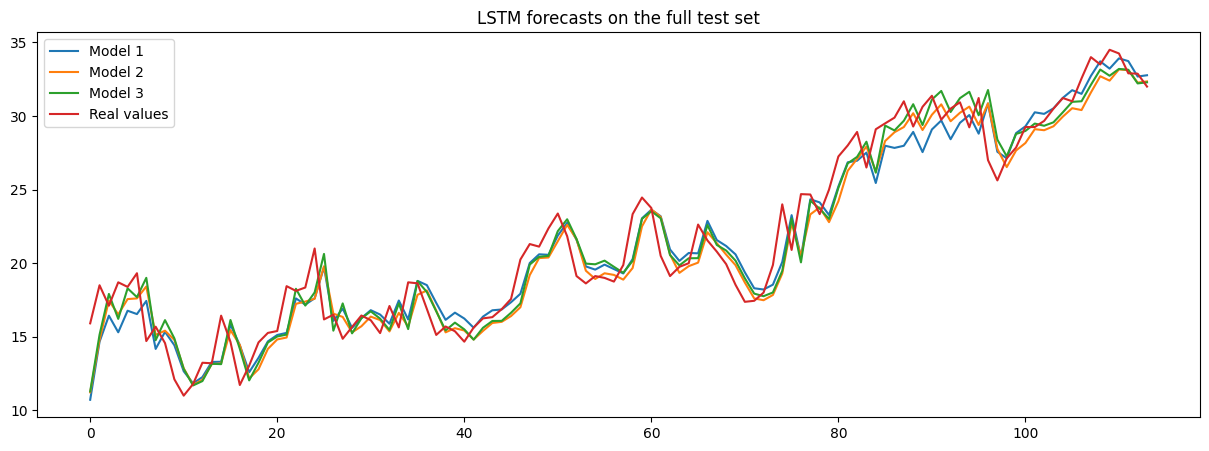

In [ ]:
### Predictions on a one time step: 

top3_forecasts = {}
plt.figure(figsize=(15,5))
for i, m in enumerate(top3, 1):
    model = m["model"]

    pred_test = rolling_horizon_lstm(
    model,
    y_train_scaled,
    y_test_scaled,
    scaler,
    lookback,
    horizon,
    device)
   
    pred_test = pred_test[:len(y_test)]
    plt.plot(range(len(pred_test)), pred_test,label=f"Model {i}")
    mae = mean_absolute_error(y_test, pred_test)
    rmse = root_mean_squared_error(y_test, pred_test)
    r2 = r2_score(y_test, pred_test)

    top3_forecasts[f"top_{i}"] = {
        "model": model,
        "params": m["params"],
        "val_rmse": m["rmse"],
        "test_pred": pred_test,
        "test_mae": mae,
        "test_rmse": rmse,
        "test_r2": r2,
    }

    print(f"\nTop {i} test performance")
    print("Params   :", m["params"])
    print(f"Test MAE : {mae:.4f}")
    print(f"Test RMSE: {rmse:.4f}")
    print(f"Test R2  : {r2:.4f}")
    
plt.plot(range(len(pred_test)), y_test, label="Real values")
plt.title("LSTM forecasts on the full test set")
plt.legend()
plt.show()


Best model test performance
Params   : {'hidden_size': 16, 'num_layers': 1, 'dropout': 0, 'lr': 0.001, 'batch_size': 8, 'weight_decay': 1e-06}
Test MAE : 1.3994
Test RMSE: 1.8051
Test R2  : 0.9187


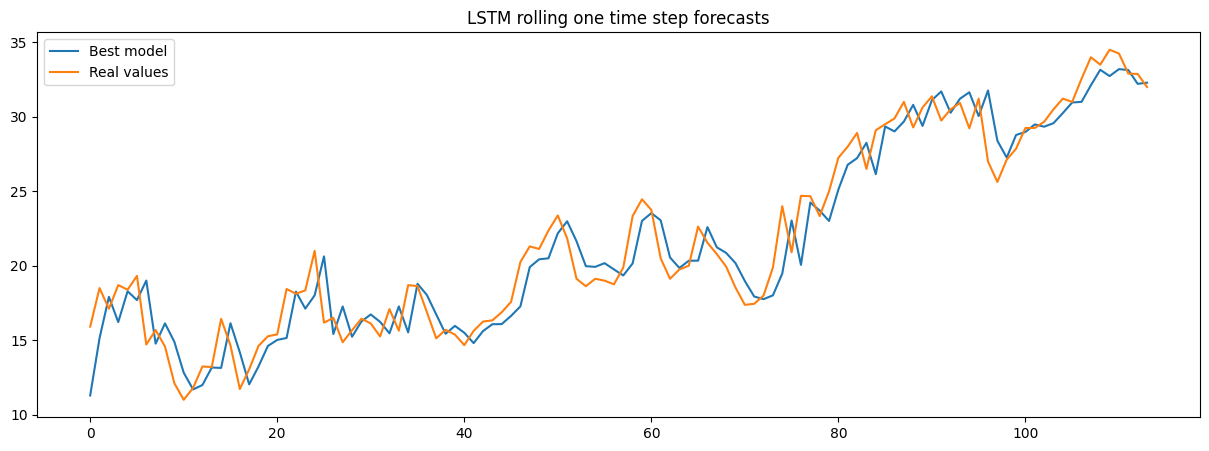

In [156]:
best_model = top3[0]["model"]
plt.figure(figsize=(15,5))
pred_test = rolling_horizon_lstm(
    model,
    y_train_scaled,
    y_test_scaled,
    scaler,
    lookback,
    horizon,
    device)
   
pred_test = pred_test[:len(y_test)]
plt.plot(range(len(pred_test)), pred_test,label=f"Best model")
mae = mean_absolute_error(y_test, pred_test)
rmse = root_mean_squared_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)


print(f"Best model test performance")
print("Params   :", m["params"])
print(f"Test MAE : {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R2  : {r2:.4f}")

plt.plot(range(len(pred_test)), y_test, label="Real values")
plt.title("LSTM rolling one time step forecasts")
plt.legend()
plt.show()


The three models who perform the best on the validation set yield similar R2 scores on the test set and RMSEs which differ little from each other. We also observe that the rmse is a bit higher than the ARIMA model for the same task. 

### Conclusion : 

Meanwhile the complex exponential smoothing (CES) is easy to start with, it is not quite useful when trying to predict on a long horizon. Without deseasoning and detrending, the ARIMA model would be useless, which is why it is more complex than the other models, which are straightforward to train and predict. The LSTM model proves quite useful for trend prediction. It yielded a similar $R^2$ than the simple sinusoidal + polynomial trend. So we can imagine that in complex cases where we have no idea on what the trend may look like, we could use a LSTM to get an idea of what the trend looks like.

We also note that the LSTM models are quite complex, consume a lot of time for the training, but yield unsatisfying performance compared to the ARIMA model which takes in less parameters, consumes less time and is more easily interpretable.